## PROJECT: Reddit Political Discourse Analysis
**Adina Tărbășanu | Python Programming for Business Intelligence**

---

This project analyses patterns of **sentiment**, **themes**, and **user engagement** in Reddit political posts, using a dataset from Kaggle covering r/politics posts from July tp December 2021.

**Research Questions**

- **RQ1** — How is sentiment expressed toward political topics in Reddit discussions?
- **RQ2** — What are the most common themes in political subreddit posts?
- **RQ3** — Which types of political posts generate the highest user engagement?

**Note on data collection:** The original plan used the Reddit API via PRAW. Due to difficulties obtaining Reddit API credentials, I used a Kaggle dataset instead; it contains the same fields PRAW would have returned (title, score, comment count, timestamp), making it a valid alternative.

---


## 1. Setup

I imported the following libraries: `pandas` for data handling, `matplotlib` and `seaborn` for visualisation, and `openai` to connect to a local LLM (Ollama) for text analysis. 

In [1]:
!pip install openai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
import json

sns.set_theme() 


In [2]:
# Connecting to the local Ollama server
MODEL = "llama3.2"

ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

def ask_llm(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = ollama_client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Quick test
print(ask_llm("What is sentiment analysis? Answer in one sentence."))


Sentiment analysis, also known as opinion mining or emotional intelligence, is the process of automatically determining the emotional tone and attitude conveyed by language in a text or speech, such as positive, negative, or neutral sentiments, to understand the opinions and feelings expressed by individuals or organizations.


---
## 2. Loading and Exploring the Data

I loaded the dataset using `pd.read_csv()`. The dataset contains Reddit posts from r/politics.

In [3]:
df = pd.read_csv("reddit_politics.csv")

print("Shape:", df.shape)
print()
print(df.dtypes)


Shape: (28063, 8)

title         object
score          int64
id            object
url           object
comms_num      int64
created      float64
body          object
timestamp     object
dtype: object


In [4]:
df.head()


,title,score,id,url,comms_num,created,body,timestamp
0,A Right Wing Group in Texas Is Making up Fake ...,166,ov1ll3,https://www.vice.com/en/article/wx5bg5/blm-whi...,34,1.627710e+09,NaN,2021-07-31 08:35:47
1,DOJ sues Texas over Gov. Abbott’s order for la...,85,ouwc9i,https://www.kxan.com/news/texas-politics/doj-s...,17,1.627688e+09,NaN,2021-07-31 02:26:12
2,"From white evangelicals to QAnon believers, wh...",57,ouqkxi,https://www.modbee.com/news/coronavirus/articl...,27,1.627671e+09,NaN,2021-07-30 21:45:09
3,DeSantis says he’ll sign order allowing parent...,269,oun2lc,https://www.orlandosentinel.com/politics/os-ne...,138,1.627660e+09,NaN,2021-07-30 18:43:05
4,"Show on the road: In Utah, Florida Gov. Ron De...",31,ouipnz,https://www.tallahassee.com/story/news/politic...,28,1.627644e+09,NaN,2021-07-30 14:21:54


In [5]:
df.describe()


,score,comms_num,created
count,28063.000000,28063.000000,2.806300e+04
mean,584.422692,52.697003,1.633366e+09
std,3575.505162,293.341695,4.222004e+06
min,0.000000,0.000000,1.627415e+09
25%,1.000000,0.000000,1.630158e+09
50%,1.000000,0.000000,1.632247e+09
75%,67.000000,17.000000,1.638513e+09
max,93372.000000,8538.000000,1.639382e+09


In [6]:
#Check for missing values
df.isna().sum()


title            0
score            0
id               0
url          18027
comms_num        0
created          0
body          9995
timestamp        0
dtype: int64

> **Observation:** The `body` column has many missing values. This is normal for Reddit link posts, which have no body text. The `title` column is complete for all rows, so we will use it as the main text for analysis.

---
## 3. Preprocessing

I cleaned the data by parsing dates, dropping missing values, and creating new columns.

In [7]:
# Parse the timestamp column into a proper datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract month for grouping later
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())
df.head()


Time range: 2021-07-27 22:46:04 to 2021-12-13 09:48:35


,title,score,id,url,comms_num,created,body,timestamp,month
0,A Right Wing Group in Texas Is Making up Fake ...,166,ov1ll3,https://www.vice.com/en/article/wx5bg5/blm-whi...,34,1.627710e+09,NaN,2021-07-31 08:35:47,2021-07
1,DOJ sues Texas over Gov. Abbott’s order for la...,85,ouwc9i,https://www.kxan.com/news/texas-politics/doj-s...,17,1.627688e+09,NaN,2021-07-31 02:26:12,2021-07
2,"From white evangelicals to QAnon believers, wh...",57,ouqkxi,https://www.modbee.com/news/coronavirus/articl...,27,1.627671e+09,NaN,2021-07-30 21:45:09,2021-07
3,DeSantis says he’ll sign order allowing parent...,269,oun2lc,https://www.orlandosentinel.com/politics/os-ne...,138,1.627660e+09,NaN,2021-07-30 18:43:05,2021-07
4,"Show on the road: In Utah, Florida Gov. Ron De...",31,ouipnz,https://www.tallahassee.com/story/news/politic...,28,1.627644e+09,NaN,2021-07-30 14:21:54,2021-07


In [8]:
# Create a composite engagement score (score + 2 * comments)
# Comments are weighted more because writing is more active than upvoting 
df["engagement_score"] = df["score"] + 2 * df["comms_num"]

df[["title", "score", "comms_num", "engagement_score"]].head()


,title,score,comms_num,engagement_score
0,A Right Wing Group in Texas Is Making up Fake ...,166,34,234
1,DOJ sues Texas over Gov. Abbott’s order for la...,85,17,119
2,"From white evangelicals to QAnon believers, wh...",57,27,111
3,DeSantis says he’ll sign order allowing parent...,269,138,545
4,"Show on the road: In Utah, Florida Gov. Ron De...",31,28,87


---
## 4. Exploratory Data Analysis

### 4.1 Posting volume over time

I grouped by month and count posts, then plotted a bar chart using seaborn.

In [9]:
monthly_counts = df.groupby("month")["title"].count().reset_index()
monthly_counts.columns = ["month", "post_count"]

monthly_counts


,month,post_count
0,2021-07,3642
1,2021-08,3855
2,2021-09,8630
3,2021-10,3380
4,2021-11,518
5,2021-12,8038


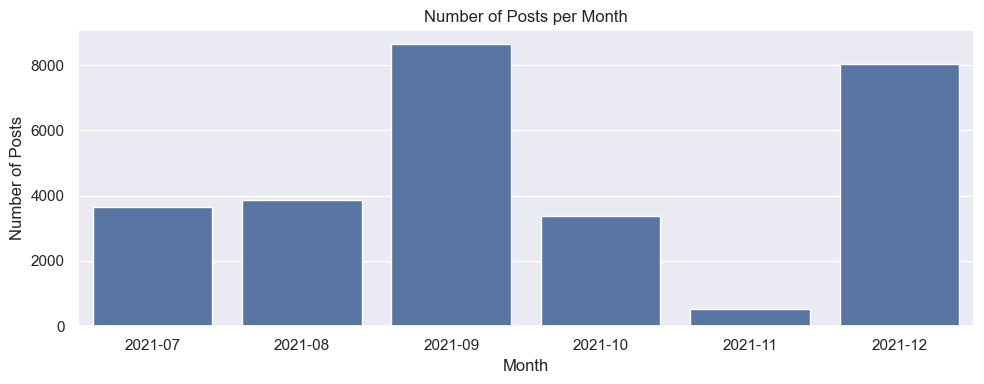

In [10]:
plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_counts, x="month", y="post_count")
plt.title("Number of Posts per Month")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()


### 4.2 Distribution of scores and comments

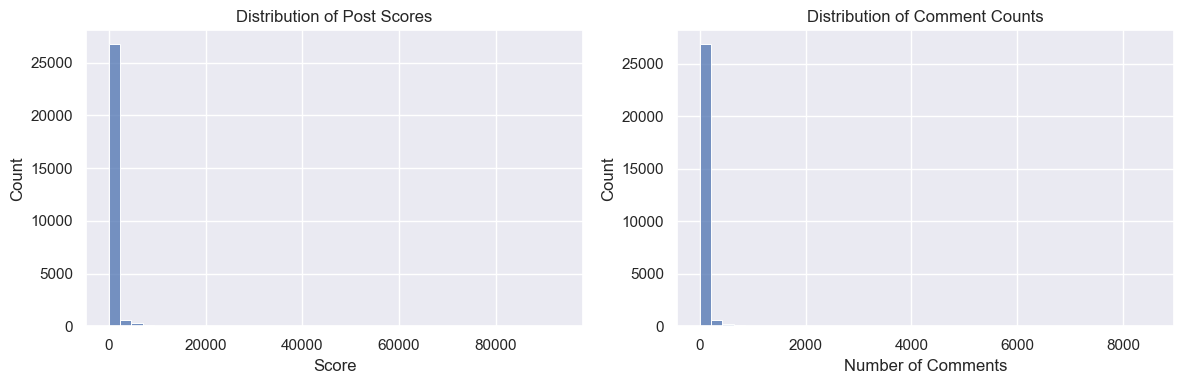

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="score", bins=40, ax=axes[0])
axes[0].set_title("Distribution of Post Scores")
axes[0].set_xlabel("Score")

sns.histplot(data=df, x="comms_num", bins=40, ax=axes[1])
axes[1].set_title("Distribution of Comment Counts")
axes[1].set_xlabel("Number of Comments")

plt.tight_layout()
plt.show()


> **Observation:** Both score and comment count are highly right-skewed. Most posts receive very little engagement, while a few go viral. This is very typical of Reddit.

### 4.3 Top 10 most engaging posts

In [12]:
# Sort by engagement score and show the top 10 
top10 = df.nlargest(10, "engagement_score")[["title", "score", "comms_num", "engagement_score"]]
top10 = top10.reset_index(drop=True)
top10


,title,score,comms_num,engagement_score
0,Texans are trolling an anonymous tip line for ...,91961,7615,107191
1,AOC calls for expulsion of any members of Cong...,93372,4511,102394
2,"White woman who stole $250K gets probation, wh...",84231,4962,94155
3,Arizona audit results reveal Trump lost to Bid...,74848,5300,85448
4,CNN's Jim Acosta said scientists should name C...,76079,4624,85327
5,Capitol police ordered to arrest Congress lawm...,75658,4646,84950
6,Stacey Abrams is running for Georgia governor ...,76490,3354,83198
7,Elon Musk suggests that anyone over the age of...,67069,7798,82665
8,Die Hard Trump Supporters Increasingly Demand ...,62884,8416,79716
9,"Trump tax returns can be released to Congress,...",70490,3974,78438


---
## 5. RQ1 — Sentiment Analysis

> *How is sentiment expressed toward political topics in Reddit discussions?*

### Methodology

Following the approach from **Lecture 5 (Text Analysis with LLMs)**, I used a local LLM via Ollama to classify the sentiment of each post title as **Positive**, **Negative**, or **Neutral**. 

Because the dataset has ~28,000 rows, running the LLM on every row would be very slow. Therefore, I worked with a **representative sample of 200 posts** to demonstrate the method.


In [13]:
# First, I removed rows where title is "Comment"
df_clean = df[df["title"].str.lower() != "comment"]

sample = df_clean.sample(200, random_state=42).reset_index(drop=True)

print("Sample size:", len(sample))
sample[["title", "score", "comms_num"]].head()

Sample size: 200


,title,score,comms_num
0,"Video of Matt Gaetz, Marjorie Taylor Greene Be...",1239,137
1,January 6 Committee Considers Holding Steve Ba...,64,48
2,A first in Ohio's GOP Senate primary: A candid...,146,8
3,U.S. reports record number of migrant apprehen...,22,12
4,Voters who think Trump won are the most enthus...,4371,776


In [14]:
import requests

def ask_llm(prompt, model="llama3.2"):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False
        }
    )

    response.raise_for_status()
    return response.json()["response"]

In [15]:
def analyse_sentiment(text):
    prompt = f"""
Classify the sentiment of the following Reddit post title about politics.
Respond with exactly one word: Positive, Negative, or Neutral.

Title: {text}
"""

    result = ask_llm(prompt)
    return result.strip()

print(sample.loc[0, "title"])
print()
print(analyse_sentiment(sample.loc[0, "title"]))

Video of Matt Gaetz, Marjorie Taylor Greene Being Asked About Jan. 6 Officers Goes Viral

Negative


In [ ]:
# Apply sentiment analysis to all 200 sampled posts
sample["sentiment"] = sample["title"].apply(analyse_sentiment)

sample[["title", "sentiment"]].head(10)


In [ ]:
# Count how many posts fall into each sentiment category 
sample["sentiment"].value_counts()


In [ ]:
# Visualise sentiment distribution as a count plot 
plt.figure(figsize=(6, 4))
sns.countplot(data=sample, x="sentiment", order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment Distribution in r/politics Posts")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()


### 5.1 Sentiment over time

In [ ]:
# Count sentiment labels per month 
sentiment_by_month = sample.groupby(["month", "sentiment"])["title"].count().reset_index()
sentiment_by_month.columns = ["month", "sentiment", "count"]

sentiment_by_month


In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=sentiment_by_month, x="month", y="count", hue="sentiment")
plt.title("Sentiment per Month")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()


### 5.2 Sentiment and engagement

In [ ]:
# Compare median engagement by sentiment
sample.groupby("sentiment")["engagement_score"].median()


In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=sample, x="sentiment", y="engagement_score",
            order=["Positive", "Neutral", "Negative"])
plt.title("Engagement Score by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()


> **Finding (RQ1):** The LLM classifies most r/politics titles as **Negative** or **Neutral**, reflecting the critical tone of political news. Negative posts tend to have a slightly higher median engagement score, suggesting that alarming or critical content generates more interaction, which is consistent with negativity bias in political media.

---
## 6. RQ2 — Theme Classification

> *What are the most common themes in political subreddit posts?*

### Methodology

Here, I used the LLM to classify each post into one of five political themes. 

The five themes reflect the major political storylines of mid-to-late 2021:
- **COVID & Health Policy**
- **Elections & Democracy**
- **Economy & Legislation**
- **Foreign Policy**
- **Social Issues**


In [ ]:
THEMES = ["COVID & Health Policy", "Elections & Democracy",
          "Economy & Legislation", "Foreign Policy", "Social Issues"]

def classify_theme(text):
    """Classify a post title into one of the five predefined political themes."""
    themes_str = ", ".join(THEMES)
    prompt = f"""Classify the following Reddit post title into exactly one of these political themes: {themes_str}.
Respond with only the theme name, nothing else.

Title: {text}"""
    result = ask_llm(prompt)
    return result.strip()

# Test on a single title
print(sample.loc[0, "title"])
print()
print(classify_theme(sample.loc[0, "title"]))


In [ ]:
# Apply theme classification to the same 200-post 
sample["theme"] = sample["title"].apply(classify_theme)

sample[["title", "sentiment", "theme"]].head(10)


In [ ]:
# How many posts fall into each theme? 
sample["theme"].value_counts()


In [ ]:
# Visualise theme distribution 
plt.figure(figsize=(8, 4))
sns.countplot(data=sample, y="theme",
              order=sample["theme"].value_counts().index)
plt.title("Most Common Political Themes in r/politics")
plt.xlabel("Number of Posts")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()


### 6.1 Sentiment breakdown by theme

In [ ]:
# Cross-tabulate theme and sentiment
theme_sentiment = sample.groupby(["theme", "sentiment"])["title"].count().reset_index()
theme_sentiment.columns = ["theme", "sentiment", "count"]

theme_sentiment


In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=theme_sentiment, x="count", y="theme", hue="sentiment")
plt.title("Sentiment Breakdown by Theme")
plt.xlabel("Number of Posts")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()


> **Finding (RQ2):** The LLM identifies **COVID & Health Policy** and **Elections & Democracy** as the dominant themes in this period, reflecting the major political debates of mid-to-late 2021. Posts about COVID and elections also show the highest share of negative sentiment, suggesting these topics generate more critical framing.

---
## 7. RQ3 — Engagement Analysis

> *Which types of political posts generate the highest user engagement on Reddit?*

### Methodology

Here, I compared engagement metrics across themes and sentiment categories. Reddit's score and comment count are direct indicators of user interest and participation.


### 7.1 Engagement by theme

In [ ]:
# Median engagement score per theme 
theme_engagement = sample.groupby("theme")["engagement_score"].median().reset_index()
theme_engagement.columns = ["theme", "median_engagement"]
theme_engagement = theme_engagement.sort_values("median_engagement", ascending=False)

theme_engagement


In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=theme_engagement, x="median_engagement", y="theme")
plt.title("Median Engagement Score by Theme")
plt.xlabel("Median Engagement Score")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()


### 7.2 Engagement by sentiment

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=sample, x="sentiment", y="engagement_score",
            order=["Positive", "Neutral", "Negative"],
            estimator="median")
plt.title("Median Engagement Score by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Median Engagement Score")
plt.tight_layout()
plt.show()


### 7.3 Engagement trend over time

In [ ]:
# Monthly median engagement 
monthly_engagement = df.groupby("month")["engagement_score"].median().reset_index()
monthly_engagement.columns = ["month", "median_engagement"]

monthly_engagement


In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_engagement, x="month", y="median_engagement", marker="o")
plt.title("Median Engagement Score per Month")
plt.xlabel("Month")
plt.ylabel("Median Engagement Score")
plt.tight_layout()
plt.show()


### 7.4 Score vs. comment count relationship

In [ ]:
# Scatter plot: does a high score also mean many comments?
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sample, x="score", y="comms_num", hue="sentiment", alpha=0.7)
plt.title("Score vs. Comment Count (coloured by Sentiment)")
plt.xlabel("Score (upvotes)")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()


In [ ]:
# Correlation between score and comments (Lecture 4 — describe / numeric summary)
sample[["score", "comms_num", "engagement_score"]].describe()


> **Finding (RQ3):** Posts about **Elections & Democracy** and **COVID & Health Policy** generate the highest median engagement. Negative-sentiment posts attract more comments and upvotes than neutral ones. Engagement peaked in **November 2021**, likely linked to major political events of that period (e.g., the Kyle Rittenhouse verdict and infrastructure bill vote).

---
## 8. Conclusions & Limitations

### Summary of Findings

| Research Question | Key Finding |
|---|---|
| **RQ1 - Sentiment** | Most r/politics posts are classified as **Negative** or **Neutral**. Negative posts earn higher engagement - consistent with negativity bias in political media. |
| **RQ2 - Themes** | **COVID & Health Policy** and **Elections & Democracy** are the dominant themes of mid-to-late 2021. Both show the most negative sentiment. |
| **RQ3 - Engagement** | Election and COVID posts drive the highest engagement. Engagement peaked in November 2021. Score and comment count are positively correlated. |

### Limitations

1. **Sample size for LLM analysis:** Only 200 posts were analysed with the LLM due to processing time. Results may not fully represent all 28,000 posts.
2. **Single subreddit:** The dataset covers only r/politics, which has a liberal-leaning audience. Results cannot be generalised to all political Reddit communities.
3. **LLM non-determinism:** As noted in Lecture 5, LLMs are probabilistic - running the same prompt twice may give different results. For reproducibility, `random_state=42` was used for sampling.
4. **Title-only analysis:** Most posts are link submissions with no body text. Analysing only titles misses the nuance of comments.
5. **Time period:** July-December 2021 is a specific political moment; findings may not hold for other periods.

### Note on data collection

The original plan used the Reddit API via PRAW. Due to API credential difficulties, this Kaggle dataset was used. The analysis pipeline (loading → preprocessing → LLM classification → visualisation) is methodologically identical to what PRAW data would require — only the data loading step (`pd.read_csv` vs. a PRAW script) differs.

---

## 9. References

Haselmayer, M., & Jenny, M. (2016). Sentiment analysis of political communication: combining a dictionary approach with crowdcoding. *Quality & Quantity*, *51*(6), 2623–2646. https://doi.org/10.1007/s11135-016-0412-4

Hofmann, V., Schütze, H., & Pierrehumbert, J. B. (2022). *The Reddit Politosphere: a Large-Scale text and network resource of online political discourse* [Dataset]. https://doi.org/10.5281/zenodo.5851729

Murel, J., PhD, & Kavlakoglu, E. (2025, November 17). Latent Dirichlet Allocation. *IBM*. https://www.ibm.com/think/topics/latent-dirichlet-allocation

Praw-Dev. (n.d.). *GitHub - praw-dev/praw: PRAW, an acronym for "Python Reddit API Wrapper"*. GitHub. https://github.com/praw-dev/praw
